In [12]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

## Utilities

In [13]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=100)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="seismic")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis="both", which="major", labelsize=9)

In [14]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

In [15]:
def plot_samples(trace, valid_gabors):
    # share x only for 1st row of subplots
    fig, axs = plt.subplots(
        nrows=2, ncols=5, dpi=150, figsize=(4, 3), sharex="row", sharey="row"
    )
    for idx, ax in enumerate(axs[0]):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace["neuron"][:, idx].ravel())
        color = "blue" if response_mean < 0.3 else "red"
        sns.histplot(
            response.ravel(), color=color, stat="probability", element="step", ax=ax
        )
        ax.text(0.05, 0.95, idx + 1, fontsize=6, transform=ax.transAxes)
        ax.text(0.7, 0.95, f"{response_mean:.2f}", fontsize=6, transform=ax.transAxes)
        ax.tick_params(axis="both", which="major", labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)
    for idx, ax in enumerate(axs[1]):
        ax.imshow(valid_gabors[idx - 5], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")

## Create filters aka Projective Fields of neurons (PFs)

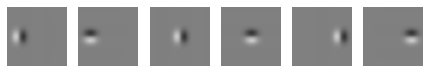

In [16]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0.0, np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

gabor_set = GaborSet(**gabor_params)

plt.figure(figsize=(10, 5))
for i, img in enumerate(gabor_set.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

### Only retain horizontal gabor in the center to get 5 PFs, one for each neuron

In [17]:
total_param_count = np.prod(gabor_set.num_params())
param_combos = [gabor_set.params_dict_from_idx(idx) for idx in range(total_param_count)]
valid_gabors = np.delete(gabor_set.images(), 2, axis=0)
param_combos.pop(2)
valid_param_combos = param_combos
valid_orientations = np.array([param["orientation"] for param in valid_param_combos])
n_neurons = valid_orientations.shape[0]

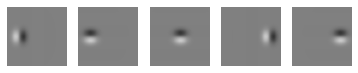

In [18]:
plt.figure(figsize=(10, 5))
for i, img in enumerate(valid_gabors):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

## Create posterior sampling `pymc` model

In [19]:
def sample_posterior(stimulus):
    lower_orientation = 0.0
    upper_orientation = np.pi
    vonmises_loc = 0.0
    vonmises_kappa = 20.0

    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", upper=np.pi)
        z = pm.Exponential(
            "neuron",
            lam=vonmises_pdf(o - valid_orientations, vonmises_loc, vonmises_kappa),
            shape=n_neurons,
        )
        x = pm.Normal(
            "stimulus",
            mu=valid_gabors.transpose(1, 2, 0) @ z,
            sigma=stimulus_sigma,
            observed=stimulus,
        )
        trace = pm.sample(1000, return_inferencedata=False)
    return trace

# Present center surround stimulus

## First a center only stimulus

(-0.5, 49.5, 49.5, -0.5)

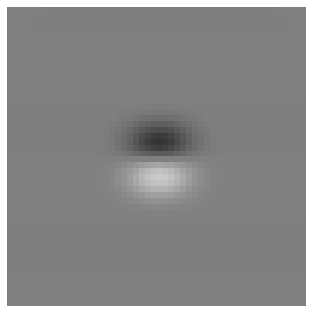

In [20]:
center_pf = valid_gabors[2]
plt.imshow(center_pf, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [21]:
trace = sample_posterior(center_pf)

AssertionError: 

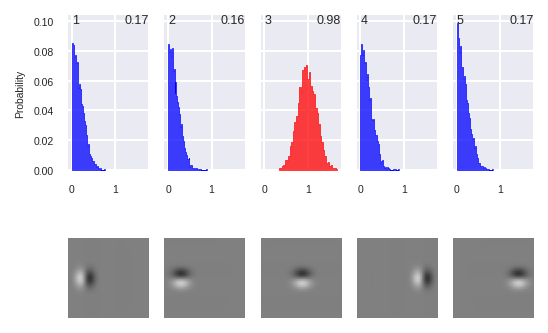

In [11]:
plot_samples(trace, valid_gabors)

## Now a center surround stimuli with circle-cut centers

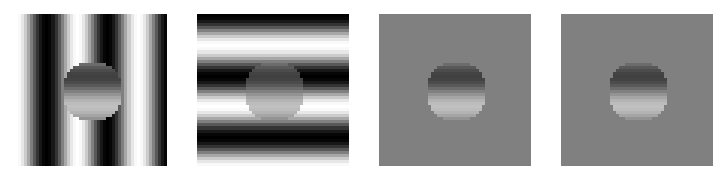

In [23]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": gabor_params["spatial_frequencies"],
    "phases_center": gabor_params["phases"],
    "phases_surround": gabor_params["phases"],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0, np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [10 / 50],
    "sizes_surround": [10 / 50],
    "contrasts_center": [0.5],
    "contrasts_surround": [1, 0],
}

center_surround = CenterSurround(**center_surround_params)
center_surround_images = center_surround.images()

fig, axs = plt.subplots(nrows=1, ncols=4, dpi=150)
for i, ax in enumerate(axs.ravel()):
    ax.imshow(center_surround_images[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

In [24]:
incongruent_surround, congruent_surround, circle_cut_center, _ = center_surround_images

In [25]:
trace_circle_cut_center = sample_posterior(circle_cut_center)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


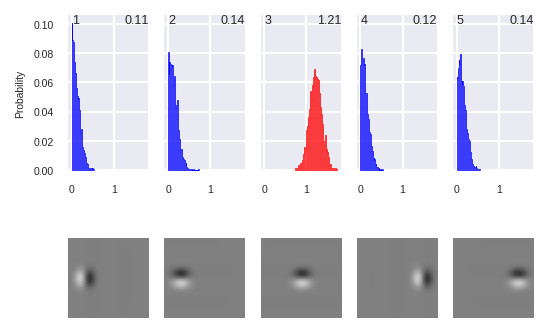

In [26]:
plot_samples(trace_circle_cut_center, valid_gabors)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


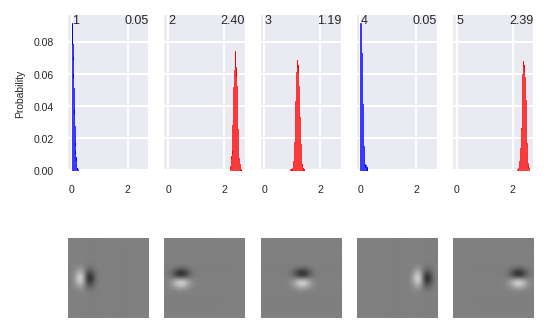

In [27]:
trace_congruent_surround = sample_posterior(congruent_surround)
plot_samples(trace_congruent_surround, valid_gabors)

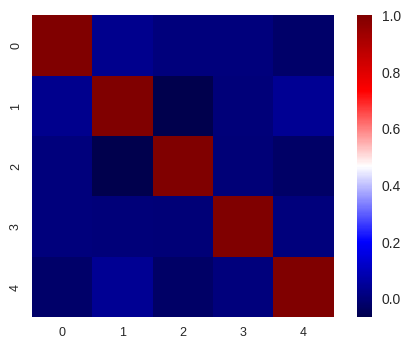

In [28]:
plot_correlation(trace_congruent_surround)

(-0.5, 49.5, 49.5, -0.5)

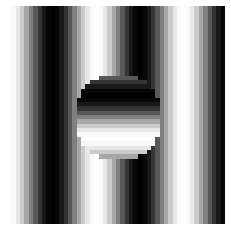

In [18]:
plt.imshow(incongruent_surround, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 11 divergences after tuning. Increase `target_accept` or reparameterize.


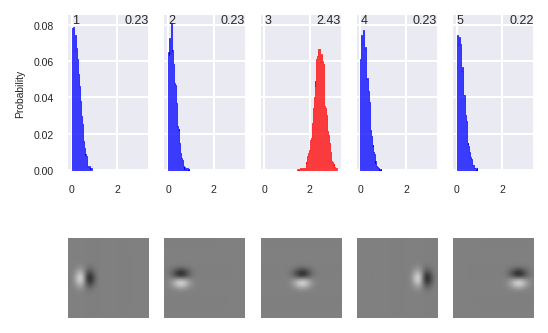

In [19]:
trace_incongruent_surround = sample_posterior(incongruent_surround)
plot_samples(trace_incongruent_surround, valid_gabors)

In [20]:
lower_orientation = 0.0
upper_orientation = np.pi
vonmises_loc = 0.0
vonmises_kappa = 2.5

stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
model = pm.Model()
with model:
    o = pm.Uniform("orientation", upper=np.pi)
    z = pm.Exponential(
        "neuron",
        lam=vonmises_pdf(o - valid_orientations, vonmises_loc, vonmises_kappa),
        shape=n_neurons,
    )
    x = pm.Normal(
        "stimulus",
        mu=torch.tensor(valid_gabors).permute(1, 2, 0) @ z,
        sigma=stimulus_sigma,
        observed=center_pf,
    )
    prior_trace = pm.sample_prior_predictive(6, random_seed=seed)

In [21]:
lambdas = np.array(
    [
        vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa)
        for orientation in prior_trace["orientation"]
    ]
)

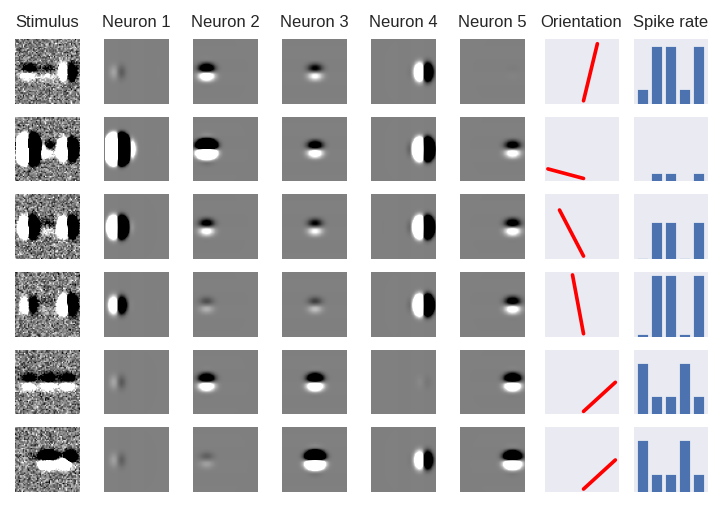

In [22]:
fig, axs = plt.subplots(nrows=6, ncols=8, dpi=150, sharex="col", sharey="col")
# name the first column of the figure as "stimulus" with small font size
axs[0, 0].set_title("Stimulus", fontsize=8)
# name rest of columns as "neuron" i
for i in range(1, 6):
    axs[0, i].set_title(f"Neuron {i}", fontsize=8)
# name the last column as "global orientation"
axs[0, 6].set_title("Orientation", fontsize=8)
axs[0, 7].set_title("Spike rate", fontsize=8)
for i, ax in enumerate(axs[:, 0]):
    ax.imshow(prior_trace["stimulus"][i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
for i, axs_features in enumerate(axs[:, 1:-2]):
    for j, ax in enumerate(axs_features):
        ax.imshow(
            valid_gabors[j] * prior_trace["neuron"][i][j], cmap="gray", vmin=-1, vmax=1
        )
        ax.axis("off")
for i, ax in enumerate(axs[:, -2]):
    # convert orientation to angle and draw line passing through the origin with that angle
    ax.plot(
        [0, np.cos(prior_trace["orientation"][i])],
        [0, np.sin(prior_trace["orientation"][i])],
        color="red",
    )
    ax.set_xticks([])
    ax.set_yticks([])
# plot bar plot of spike rates in the last column
for i, ax in enumerate(axs[:, -1]):
    ax.bar(np.arange(1, 6), lambdas[i])
    ax.set_xticks([])
    ax.set_yticks([])